In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:

df = pd.read_csv("../Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:

# Check column names
print("Columns:")
print(df.columns.tolist())

# Check data types and missing values
print("\nDataset information:")
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check churn distribution
print("\nChurn distribution:")
print(df["Churn"].value_counts())


Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


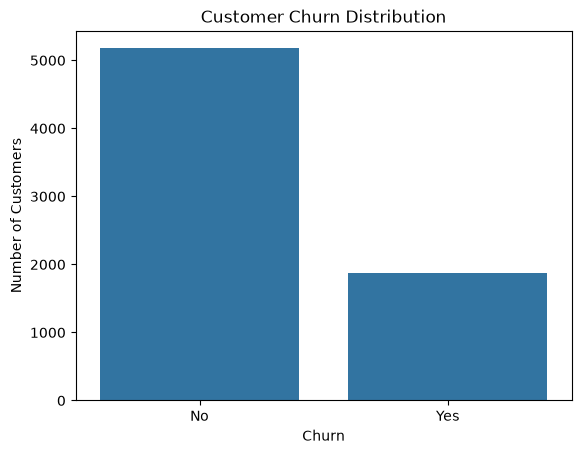

In [5]:

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check churn counts and percentages
print(df["Churn"].value_counts())
print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

# Visualise churn distribution
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


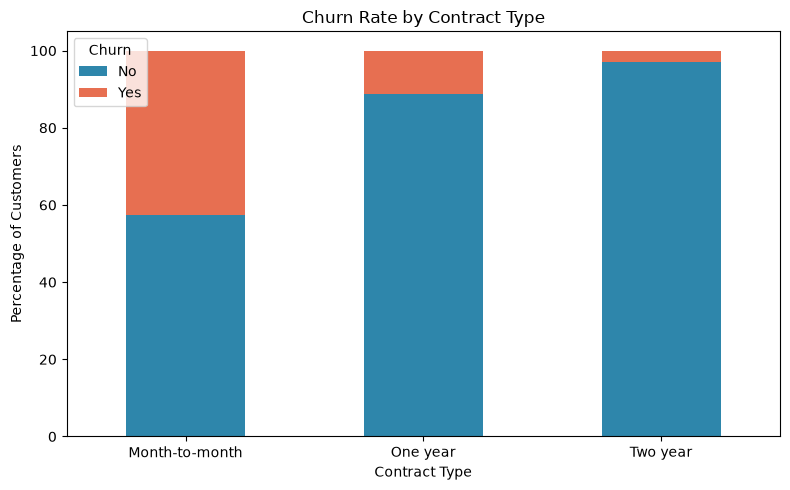

In [6]:

# Churn rate by contract
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

# Visualisation
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#2E86AB", "#E76F51"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.legend(title="Churn")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


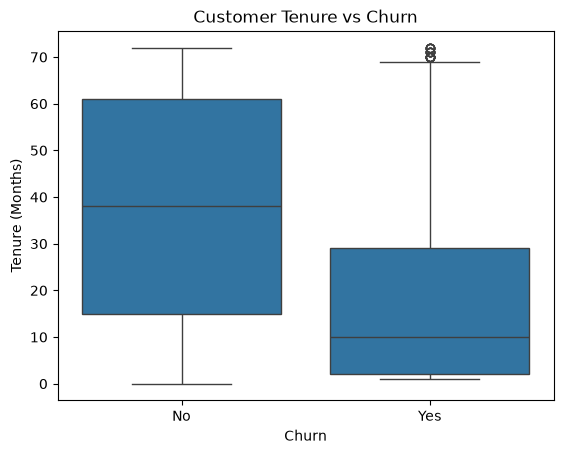

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [7]:

# Compare tenure for churned and retained customers
sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

# Average tenure
print(df.groupby("Churn")["tenure"].mean())


Dataset shape: (7043, 21)

Missing values:
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Duplicate rows: 0

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Numerical summary:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2555.34
Yes,17.98,74.44,1531.80


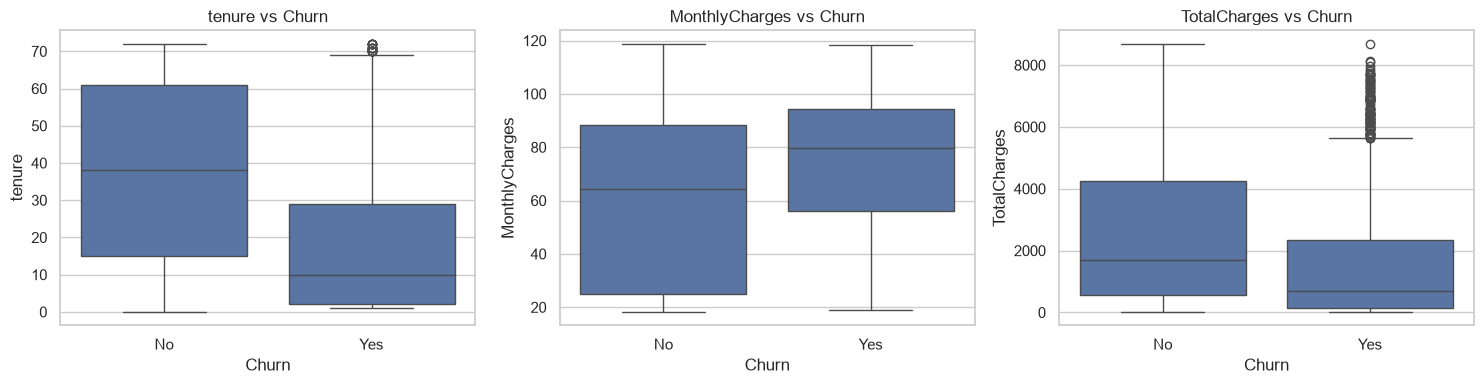


Churn rate by Contract (%):


Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8



Churn rate by InternetService (%):


Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4



Churn rate by PaymentMethod (%):


...

Churn,No,Yes
DeviceProtection,,
No,60.9,39.1
No internet service,92.6,7.4
Yes,77.5,22.5



Churn rate by StreamingTV (%):


Churn,No,Yes
StreamingTV,,
No,66.5,33.5
No internet service,92.6,7.4
Yes,69.9,30.1



Churn rate by StreamingMovies (%):


Churn,No,Yes
StreamingMovies,,
No,66.3,33.7
No internet service,92.6,7.4
Yes,70.1,29.9


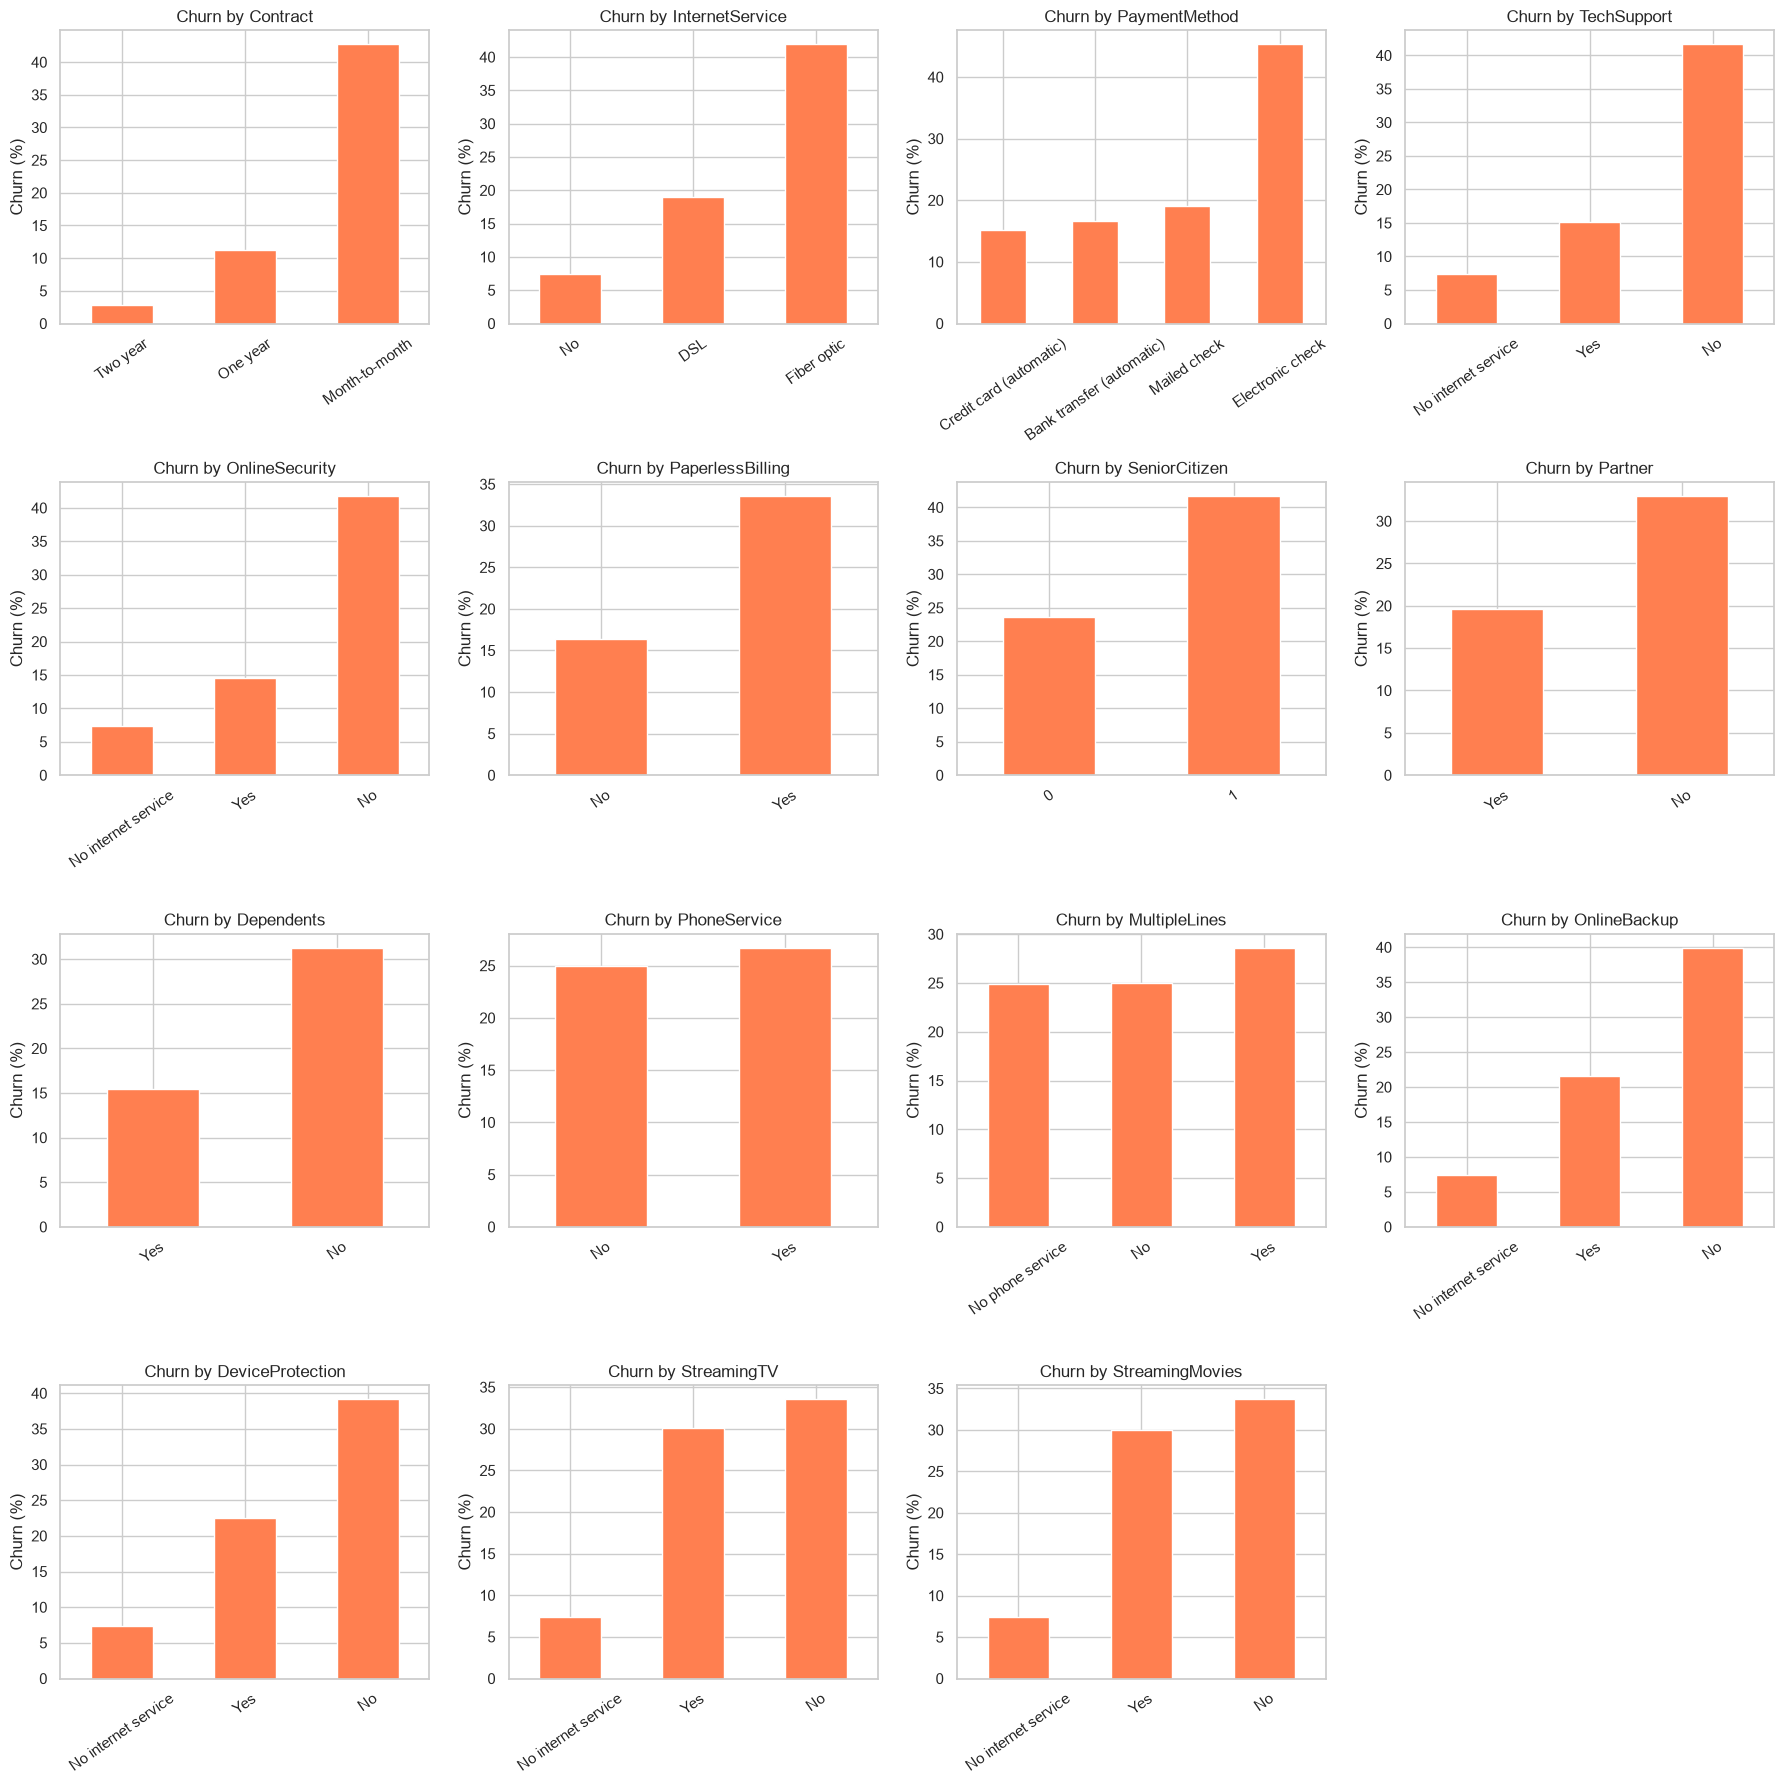

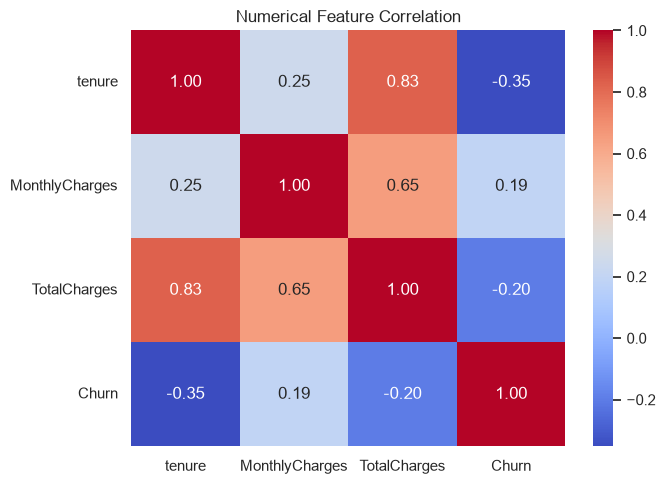


Churn rate by tenure group (%):


TenureGroup
0-12     47.44
13-24    28.71
25-48    20.39
49-60    14.42
61-72     6.61
Name: Churn, dtype: float64

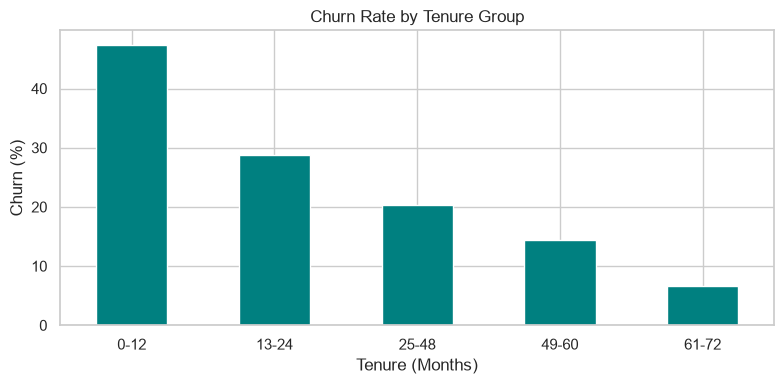


EDA COMPLETE
Total customers: 7043
Overall churn rate: 26.54 %
Average tenure: 32.37 months
Average monthly charges: 64.76


In [8]:

# ==========================================
# COMPLETE CUSTOMER CHURN - EDA
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Data cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# 2. Target distribution
print("\nChurn distribution:")
print(df["Churn"].value_counts())
print("\nChurn rate (%):")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

# 3. Numerical feature analysis
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

print("\nNumerical summary:")
display(df.groupby("Churn")[numeric_cols].mean().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, ax in zip(numeric_cols, axes):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} vs Churn")
plt.tight_layout()
plt.show()

# 4. Categorical feature analysis
categorical_cols = [
    "Contract", "InternetService", "PaymentMethod",
    "TechSupport", "OnlineSecurity", "PaperlessBilling",
    "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "OnlineBackup",
    "DeviceProtection", "StreamingTV", "StreamingMovies"
]

# Churn percentage within each category
for col in categorical_cols:
    print(f"\nChurn rate by {col} (%):")
    display(
        (pd.crosstab(df[col], df["Churn"], normalize="index") * 100)
        .round(1)
    )

# 5. Visualise categorical churn rates
fig, axes = plt.subplots(4, 4, figsize=(18, 18))
axes = axes.flatten()

for col, ax in zip(categorical_cols, axes):
    rates = pd.crosstab(
        df[col], df["Churn"], normalize="index"
    ) * 100
    if "Yes" in rates.columns:
        rates["Yes"].sort_values().plot(
            kind="bar", ax=ax, color="coral"
        )
    ax.set_title(f"Churn by {col}")
    ax.set_ylabel("Churn (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)

for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# 6. Correlation between numeric features
encoded = df[numeric_cols].copy()
encoded["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

plt.figure(figsize=(7, 5))
sns.heatmap(encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numerical Feature Correlation")
plt.tight_layout()
plt.show()

# 7. Churn rate by tenure groups
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=["0-12", "13-24", "25-48", "49-60", "61-72"]
)

tenure_churn = (
    df.groupby("TenureGroup", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("\nChurn rate by tenure group (%):")
display(tenure_churn.round(2))

tenure_churn.plot(kind="bar", figsize=(8, 4), color="teal")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 8. Business summary
print("\nEDA COMPLETE")
print("Total customers:", len(df))
print("Overall churn rate:", round((df["Churn"] == "Yes").mean()*100, 2), "%")
print("Average tenure:", round(df["tenure"].mean(), 2), "months")
print("Average monthly charges:", round(df["MonthlyCharges"].mean(), 2))


In [9]:
# ==========================================
# DATA PREPROCESSING
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Make a copy
data = df.copy()

# Remove customer ID
data.drop("customerID", axis=1, inplace=True)

# Remove the EDA-only tenure group for now
# We'll create our feature engineering properly below
if "TenureGroup" in data.columns:
    data.drop("TenureGroup", axis=1, inplace=True)

# Convert target: No = 0, Yes = 1
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

# Separate features and target
X = data.drop("Churn", axis=1)
y = data["Churn"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

print("\nTarget distribution:")
print(y.value_counts())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Shape of X: (7043, 19)
Shape of y: (7043,)


C:\Users\yashy\AppData\Local\Temp\ipykernel_50588\561657061.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [10]:
# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")

Training samples: 5634
Testing samples: 1409
Training churn rate: 26.54 %
Testing churn rate: 26.54 %


In [11]:
# ==========================================
# PREPROCESSING PIPELINE
# ==========================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Create Logistic Regression pipeline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation
print("LOGISTIC REGRESSION")
print("=" * 40)
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall   :", round(recall_score(y_test, y_pred_lr), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_lr), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lr), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.604
ROC-AUC  : 0.8419

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [13]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("RANDOM FOREST")
print("=" * 40)
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
Accuracy : 0.7658
Precision: 0.5521
Recall   : 0.623
F1 Score : 0.5854
ROC-AUC  : 0.8218

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.55      0.62      0.59       374

    accuracy                           0.77      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



In [15]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting pipeline
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("GRADIENT BOOSTING")
print("=" * 40)
print("Accuracy :", round(accuracy_score(y_test, y_pred_gb), 4))
print("Precision:", round(precision_score(y_test, y_pred_gb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_gb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_gb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_gb), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

GRADIENT BOOSTING
Accuracy : 0.8027
Precision: 0.6644
Recall   : 0.5187
F1 Score : 0.5826
ROC-AUC  : 0.8432

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [16]:
# ==========================================
# MODEL COMPARISON
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

# Round the values
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
1,Random Forest,0.7658,0.5521,0.6230,0.5854,0.8218
2,Gradient Boosting,0.8027,0.6644,0.5187,0.5826,0.8432


In [17]:
from sklearn.model_selection import RandomizedSearchCV

# Gradient Boosting pipeline for tuning
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

# Hyperparameter search space
param_grid = {
    "model__n_estimators": [100, 150, 200, 250],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 1.0]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train
random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(random_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 2, 'model__learning_rate': 0.05}

Best CV ROC-AUC:
0.8493


In [18]:
# ==========================================
# FINAL MODEL EVALUATION
# ==========================================

best_model = random_search.best_estimator_

# Predictions
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

# Metrics
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_roc_auc = roc_auc_score(y_test, y_prob_final)

print("FINAL TUNED GRADIENT BOOSTING MODEL")
print("=" * 50)
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

FINAL TUNED GRADIENT BOOSTING MODEL
Accuracy : 0.7991
Precision: 0.6574
Recall   : 0.5080
F1 Score : 0.5732
ROC-AUC  : 0.8460

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



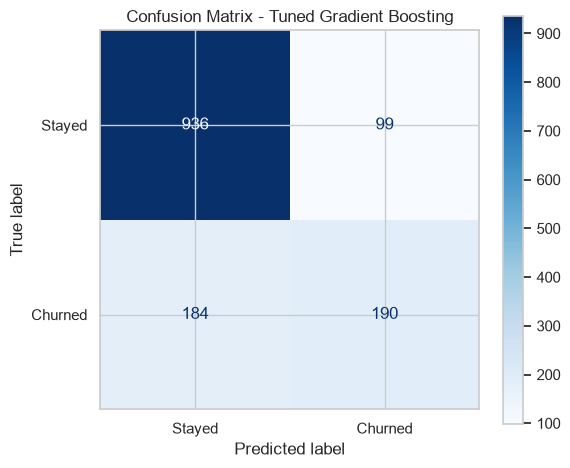

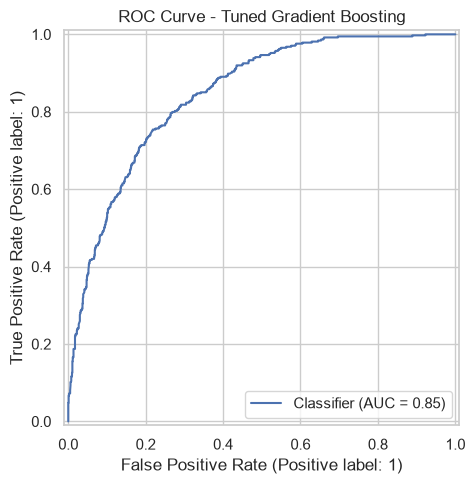

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# ==========================================
# CONFUSION MATRIX
# ==========================================

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - Tuned Gradient Boosting")
plt.tight_layout()
plt.show()


# ==========================================
# ROC CURVE
# ==========================================

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_final,
    ax=ax
)

plt.title("ROC Curve - Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

# Get the preprocessing part of the trained model
preprocessor_fitted = best_model.named_steps["preprocessor"]

# Get the trained Gradient Boosting model
gb_fitted = best_model.named_steps["model"]

# Get feature names after one-hot encoding
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance
importance = gb_fitted.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

# Display top 15
print("Top 15 Features:")
display(feature_importance.head(15))

Top 15 Features:


,Feature,Importance
36,cat__Contract_Month-to-month,0.355769
1,num__tenure,0.171617
16,cat__InternetService_Fiber optic,0.123239
18,cat__OnlineSecurity_No,0.081225
27,cat__TechSupport_No,0.058433
43,cat__PaymentMethod_Electronic check,0.057615
3,num__TotalCharges,0.048879
2,num__MonthlyCharges,0.039937
39,cat__PaperlessBilling_No,0.011381
38,cat__Contract_Two year,0.011329


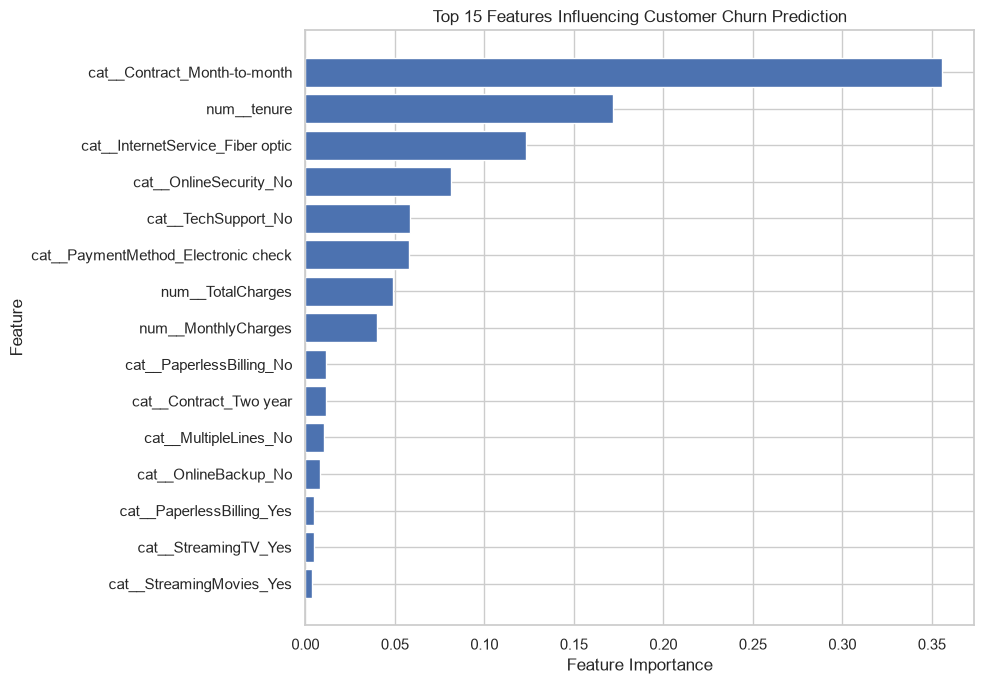

In [21]:
# ==========================================
# TOP 15 FEATURE IMPORTANCE
# ==========================================

top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Customer Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [22]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../Models", exist_ok=True)

# Save final tuned model
model_path = "../Models/customer_churn_model.pkl"

joblib.dump(best_model, model_path)

print("Model saved successfully!")
print("Location:", model_path)

Model saved successfully!
Location: ../Models/customer_churn_model.pkl


In [23]:
# Load the saved model to verify
loaded_model = joblib.load(model_path)

print("Saved model loaded successfully!")
print(type(loaded_model))

Saved model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>
